Part 1: Data Loading and Preview

This block handles the imports, loads the CSV file, and displays the initial rows to verify the data structure.

Data Preview:


,folder_id,json_date,json_lat,json_lon,methane_rate,fold,AFRI1600,AFRI2100,ANDWI,ARI,...,WI2,WI2015,WRI,bNIRv,mND705,mSR705,sNIRvLSWI,sNIRvNDVILSWIP,sNIRvNDVILSWIS,sNIRvSWIR
0,00ba2312cab12f013293d0c63f194223,8.10.2024,45.47,55.09,559,5,0.102815,0.332104,-0.182554,0.959933,...,-0.202430,-19.470171,0.720440,0.064215,0.052627,0.185183,0.003944,-0.000702,0.025505,-0.025324
1,00e44955d3619ddf3e59b97515b3c3ef,29.03.2024,39.62,53.49,145,3,0.228814,0.403648,0.048607,-1.788165,...,0.046112,-7.225442,2.223270,0.029368,2.941877,-0.030725,-0.003307,-0.002024,0.001455,-0.030626
2,011c4f5a197b65c79fd2e026dd0d99ec,4.04.2024,32.34,-103.30,120,3,0.017329,0.211532,-0.333391,2.107337,...,-0.417119,-33.453747,0.548426,0.086260,0.068474,0.238348,-0.033691,-0.004302,0.001127,-0.030413
3,014022e9d73f44dc6eb78af128744e42,12.04.2024,27.38,95.27,23,4,0.328035,0.566907,0.009556,-0.067776,...,0.225956,2.427412,0.889133,0.022215,0.168150,0.007070,0.111648,0.013643,0.152455,0.003191
4,014e9bf6cb512824596960f410f37ea3,19.06.2024,63.84,69.67,42,2,0.374108,0.670021,-0.230286,2.485754,...,0.127944,-10.552881,0.545679,0.078566,0.561974,0.138210,0.089603,0.047963,0.191354,0.093739


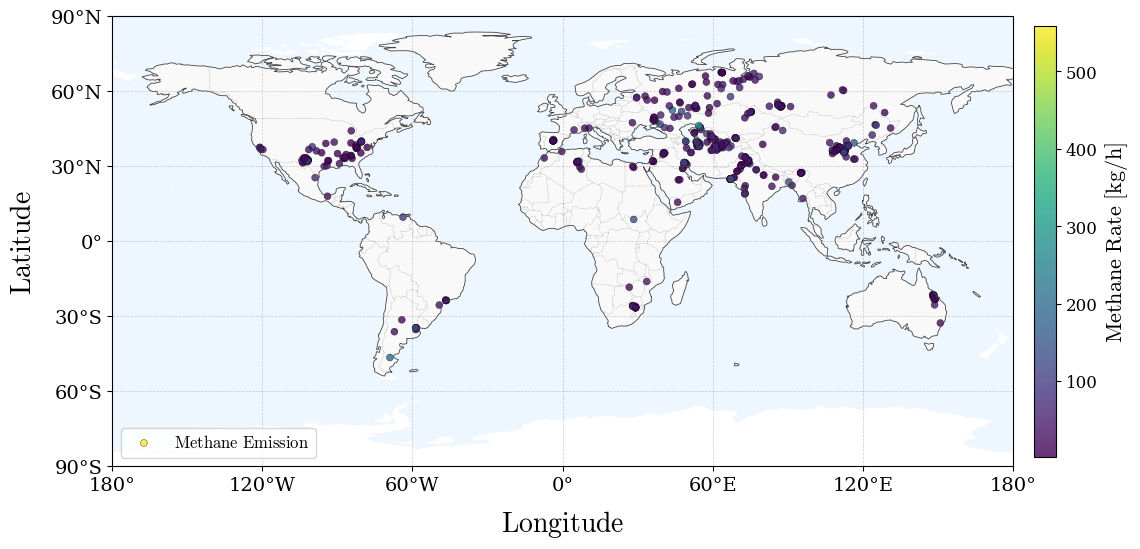

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from IPython.display import display

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif"
})

# --- LOADING DATA ---
file_path = 'useR_sentinel2_indices_mean.csv'
df = pd.read_csv(file_path, sep=';')

print("Data Preview:")
display(df.head())

# --- PREPARING THE MAP ---
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
ax.add_feature(cfeature.OCEAN, facecolor='#eef6ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='#444444')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', edgecolor='#666666')

sc = ax.scatter(
    df['json_lon'],
    df['json_lat'],
    c=df['methane_rate'],
    cmap='viridis',
    s=25,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3,
    transform=ccrs.PlateCarree(),
    label=r'$\mathrm{Methane\ Emission}$'
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label(r'$\mathrm{Methane\ Rate\ [kg/h]}$', fontsize=16)
cbar.ax.tick_params(labelsize=12)

ax.set_xticks([-180, -120, -60, 0, 60, 120, 180], crs=ccrs.PlateCarree())
ax.set_yticks([-90, -60, -30, 0, 30, 60, 90], crs=ccrs.PlateCarree())
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$\mathrm{Longitude}$', fontsize=20, labelpad=10)
plt.ylabel(r'$\mathrm{Latitude}$', fontsize=20, labelpad=10)
plt.legend(loc='lower left', frameon=True, fontsize=12)


Part 2: Model Training and Multi-Level Evaluation

This script allows to specify feature variables, trains a Random Forest model, saves it using the required naming convention, and outputs performance metrics per fold, month, and area.

In [2]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings('ignore')

# --- DATA PREPARATION ---
df_model = df.copy()
# IMPORTANT: Correct date parsing for Day.Month.Year format
df_model['json_date'] = pd.to_datetime(df_model['json_date'], dayfirst=True)

user_features = ['NDWI', 'NDVI', 'FWEI', 'GNDVI', 'EVI']
target = 'methane_rate'

# Handle missing values
df_model[user_features] = df_model[user_features].fillna(df_model[user_features].median())
df_model[target] = df_model[target].fillna(df_model[target].median())

# METRICS FUNCTION
def calculate_all_metrics(group):
    y_true = group[target].values
    y_pred = group['predicted'].values
    if len(y_true) < 1: return pd.Series(dtype='float64')

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    smape = 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

    if len(y_true) > 1 and np.std(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
        try: corr, _ = pearsonr(y_true, y_pred)
        except: corr = 0.0
    else:
        r2, corr = np.nan, np.nan

    return pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape, "sMAPE": smape, "Pearson_R": corr, "Count": int(len(y_true))})

# --- TRAINING LOOP ---
all_predictions = []
print(f"Training Random Forest on: {user_features}\n")

for f in sorted(df_model['fold'].unique()):
    train_df = df_model[df_model['fold'] != f]
    test_df = df_model[df_model['fold'] == f]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(train_df[user_features], train_df[target])

    # Per shared personalization: saving model with fold index
    model_filename = f"rf_methane_fold_{int(f)}.joblib"
    joblib.dump(model, model_filename)

    preds = model.predict(test_df[user_features])
    test_res = test_df.copy()
    test_res['predicted'] = preds
    all_predictions.append(test_res)

    m = calculate_all_metrics(test_res)
    print(f"Fold {int(f)} -> MAE: {m['MAE']:.4f} | R2: {m['R2']:.4f} | Pearson: {m['Pearson_R']:.4f}")

full_results = pd.concat(all_predictions)

# --- GLOBAL REPORT ---
print("\n" + "="*90)
print("PART 2: GLOBAL REPORT (Consolidated Metrics)")
print("="*90)
print(calculate_all_metrics(full_results).to_string())

Training Random Forest on: ['NDWI', 'NDVI', 'FWEI', 'GNDVI', 'EVI']

Fold 1 -> MAE: 30.9795 | R2: -0.0676 | Pearson: 0.1770
Fold 2 -> MAE: 28.1999 | R2: -0.1499 | Pearson: 0.1709
Fold 3 -> MAE: 27.4422 | R2: 0.0168 | Pearson: 0.2562
Fold 4 -> MAE: 29.7897 | R2: -0.2801 | Pearson: 0.2194
Fold 5 -> MAE: 34.9371 | R2: -0.0516 | Pearson: 0.0849

PART 2: GLOBAL REPORT (Consolidated Metrics)
MAE           30.259043
RMSE          48.179777
R2            -0.087060
MAPE           1.293431
sMAPE         64.563687
Pearson_R      0.164455
Count        439.000000


Part 3: Seasonal Analysis (Metrics per Month)

In [3]:
# Process months
full_results['month_num'] = full_results['json_date'].dt.month
month_names_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                   7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

report_month_raw = full_results.groupby('month_num').apply(calculate_all_metrics).reset_index()

# Construct 12-month report
full_year = pd.DataFrame({'month_num': range(1, 13)})
full_year['Month'] = full_year['month_num'].map(month_names_map)
seasonal_report = pd.merge(full_year, report_month_raw, on='month_num', how='left')

print("\n" + "="*90)
print("PART 3: SEASONAL REPORT (Metrics per Month)")
print("="*90)
print(seasonal_report.to_string(index=False, na_rep='N/A'))

# Save results to CSV
seasonal_report.to_csv('analysis_metrics_per_month.csv', index=False)


PART 3: SEASONAL REPORT (Metrics per Month)
 month_num Month       MAE      RMSE        R2     MAPE     sMAPE  Pearson_R  Count
         1   Jan 31.976216 38.874805 -0.044440 1.583665 70.828550   0.331537   37.0
         2   Feb 34.075000 47.057975 -0.163513 1.651636 73.352000   0.056012   42.0
         3   Mar 32.648125 55.834317 -0.873480 1.292540 57.254849   0.107342   32.0
         4   Apr 44.464722 58.826396 -0.127519 1.051546 72.671044   0.121840   36.0
         5   May 17.321395 23.761821  0.169474 0.924913 44.546949   0.549481   43.0
         6   Jun 23.688810 32.029678 -0.082509 1.087576 59.110974   0.205568   42.0
         7   Jul 24.616857 31.233753 -0.202278 1.053986 66.563491   0.194128   35.0
         8   Aug 27.935610 37.802731 -0.990121 1.571945 67.655379   0.035250   41.0
         9   Sep 24.975962 32.244957 -0.094586 1.538675 67.136739   0.185141   52.0
        10   Oct 39.579839 80.889619 -0.008982 0.991150 63.909596   0.297077   62.0
        11   Nov       N/A     

Part 4: Continental Analysis (Metrics per Region)

In [3]:
# Continent Mapping Logic
def get_continent(lat, lon):
    if lat > 15 and -170 < lon < -50: return 'North America'
    if lat < 15 and -100 < lon < -30: return 'South America'
    if 35 < lat < 75 and -25 < lon < 45: return 'Europe'
    if -35 < lat < 35 and -20 < lon < 55:
        if lat > 15 and lon > 32: return 'Middle East'
        return 'Africa'
    if 15 < lat < 50 and 32 < lon < 75: return 'Middle East'
    if lat > -10 and 60 < lon < 180: return 'Asia'
    if lat < -10 and 110 < lon < 180: return 'Oceania'
    return 'Other'

full_results['continent'] = full_results.apply(lambda x: get_continent(x['json_lat'], x['json_lon']), axis=1)

# Generate and display the Continental Report
report_continent = full_results.groupby('continent').apply(calculate_all_metrics).reset_index()

print("\n" + "="*90)
print("PART 4: CONTINENTAL REPORT (Metrics per Continent)")
print("="*90)
print(report_continent.sort_values('MAE').to_string(index=False))

# Save results to CSV
report_continent.to_csv('analysis_metrics_per_continent.csv', index=False)


PART 4: CONTINENTAL REPORT (Metrics per Continent)
    continent       MAE      RMSE        R2     MAPE     sMAPE  Pearson_R  Count
        Other 15.825263 22.046152  0.409499 1.988887 57.358813   0.721695   19.0
      Oceania 16.264167 19.396799 -3.321790 1.145367 64.116872  -0.041322   12.0
North America 24.225000 30.750689 -0.068516 1.537003 70.230108   0.179509   58.0
       Africa 25.590741 34.245042 -0.682135 1.504339 71.688370  -0.116878   27.0
         Asia 27.512241 36.568697 -0.249555 1.067405 63.021789   0.048195  116.0
       Europe 31.890000 43.829912 -0.300824 2.162952 83.892969  -0.047503   37.0
  Middle East 36.577308 64.464781 -0.148630 1.071187 57.584648   0.088770  156.0
South America 43.890000 56.249216 -0.207511 1.111868 76.966713   0.016876   14.0
